In [1]:
#pip install datasets pillow pandas tqdm

In [9]:
## STEP 1: IMPORTS AND CONFIGURATION

import os
import json
from datasets import load_dataset
from PIL import Image
from collections import defaultdict
from tqdm import tqdm
import random

In [ ]:
# 25 Selected Classes (CORRECT indices from detection-datasets/coco)

SELECTED_CLASSES = {
    'person': 0,
    'bicycle': 1,
    'car': 2,
    'motorcycle': 3,
    'airplane': 4,
    'bus': 5,
    'train': 6,
    'truck': 7,
    'traffic light': 9,
    'stop sign': 11,
    'bench': 13,
    'bird': 14,
    'cat': 15,
    'dog': 16,
    'horse': 17,
    'cow': 19,
    'elephant': 20,
    'bottle': 39,
    'cup': 41,
    'bowl': 45,
    'pizza': 53,
    'cake': 55,
    'chair': 56,
    'couch': 57,
    'potted plant': 58,
    'bed': 59
}

IMAGES_PER_CLASS = 100
BASE_DIR = "smartvision_dataset"

In [11]:
## STEP 2: LOAD COCO DATASET FROM HUGGING FACE

print("📥 Loading COCO dataset in STREAMING mode (no download)...")
dataset = load_dataset("detection-datasets/coco", split="train", streaming=True)
print("✅ Dataset loaded in streaming mode!")

📥 Loading COCO dataset in STREAMING mode (no download)...
✅ Dataset loaded in streaming mode!


In [5]:
## STEP 3: COLLECT IMAGES FROM STREAM

print("\n🔍 Starting image collection from COCO dataset stream...")
print(f"🎯 Target: {IMAGES_PER_CLASS} images per class")
print()

# Initialize storage for collected images
class_images = {class_name: [] for class_name in SELECTED_CLASSES.keys()}
class_counts = {class_name: 0 for class_name in SELECTED_CLASSES.keys()}

# Progress tracking
total_collected = 0
images_processed = 0
max_iterations = 50000  # Safety limit

print("⏳ Processing images from stream...")
print("💡 Progress updates every 100 images collected")
print()

# Iterate through streaming dataset
for idx, item in enumerate(dataset):

    images_processed += 1

    # Progress update every 1000 images processed
    if images_processed % 1000 == 0:
        print(f"📊 Processed {images_processed} images | Collected {total_collected}/{len(SELECTED_CLASSES) * IMAGES_PER_CLASS}")

    # Safety check
    if images_processed >= max_iterations:
        print(f"⚠️ Reached safety limit of {max_iterations} iterations")
        break

    # Check if we have enough images for ALL classes
    if all(count >= IMAGES_PER_CLASS for count in class_counts.values()):
        print("🎉 Successfully collected 100 images for ALL classes!")
        break

    # Get annotations from current image
    annotations = item['objects']
    categories = annotations['category']

    # Check if any of our target classes are in this image
    for cat_id in categories:
        for class_name, class_id in SELECTED_CLASSES.items():
            if cat_id == class_id and class_counts[class_name] < IMAGES_PER_CLASS:

                # Store the ACTUAL image data (not just index!)
                class_images[class_name].append({
                    'image': item['image'],           # PIL Image object
                    'annotations': item['objects'],   # Annotations
                    'idx': images_processed           # For naming
                })

                class_counts[class_name] += 1
                total_collected += 1

                # Progress update every 100 collected
                if total_collected % 100 == 0:
                    print(f"✓ Collected {total_collected}/{len(SELECTED_CLASSES) * IMAGES_PER_CLASS} images")

                break  # Only count once per class

print()
print("="*60)
print("📊 COLLECTION COMPLETE:")
print("="*60)
print(f"Images Processed: {images_processed}")
print(f"Images Collected: {total_collected}")
print()
for class_name, count in sorted(class_counts.items()):
    status = "✅" if count >= IMAGES_PER_CLASS else "⚠️"
    print(f"{status} {class_name:20s}: {count:3d} images")
print("="*60)


🔍 Starting image collection from COCO dataset stream...
🎯 Target: 100 images per class

⏳ Processing images from stream...
💡 Progress updates every 100 images collected



✓ Collected 100/2600 images
✓ Collected 200/2600 images
✓ Collected 300/2600 images
✓ Collected 400/2600 images
✓ Collected 500/2600 images
✓ Collected 600/2600 images
✓ Collected 700/2600 images
✓ Collected 800/2600 images
✓ Collected 900/2600 images
✓ Collected 1000/2600 images
✓ Collected 1100/2600 images
✓ Collected 1200/2600 images
✓ Collected 1300/2600 images
✓ Collected 1400/2600 images
✓ Collected 1500/2600 images
✓ Collected 1600/2600 images
📊 Processed 1000 images | Collected 1682/2600
✓ Collected 1700/2600 images
✓ Collected 1800/2600 images
✓ Collected 1900/2600 images
✓ Collected 2000/2600 images
✓ Collected 2100/2600 images
✓ Collected 2200/2600 images
✓ Collected 2300/2600 images
📊 Processed 2000 images | Collected 2364/2600
✓ Collected 2400/2600 images
✓ Collected 2500/2600 images
📊 Processed 3000 images | Collected 2543/2600
📊 Processed 4000 images | Collected 2559/2600
📊 Processed 5000 images | Collected 2574/2600
✓ Collected 2600/2600 images
🎉 Successfully collected 

In [6]:
## STEP 4: CREATE FOLDER STRUCTURE

print("\n📁 Creating project folder structure...")
print()

# Create main directory
os.makedirs(BASE_DIR, exist_ok=True)

# Create subdirectories for Classification task
os.makedirs(f"{BASE_DIR}/classification/train", exist_ok=True)
os.makedirs(f"{BASE_DIR}/classification/val", exist_ok=True)
os.makedirs(f"{BASE_DIR}/classification/test", exist_ok=True)

# Create subdirectories for Detection task
os.makedirs(f"{BASE_DIR}/detection/images", exist_ok=True)
os.makedirs(f"{BASE_DIR}/detection/labels", exist_ok=True)

# Create class folders inside train/val/test
for class_name in SELECTED_CLASSES.keys():
    os.makedirs(f"{BASE_DIR}/classification/train/{class_name}", exist_ok=True)
    os.makedirs(f"{BASE_DIR}/classification/val/{class_name}", exist_ok=True)
    os.makedirs(f"{BASE_DIR}/classification/test/{class_name}", exist_ok=True)

print("✅ Folder structure created successfully!")
print()
print("📂 Structure:")
print(f"""
{BASE_DIR}/
├── classification/
│   ├── train/
│   │   ├── person/
│   │   ├── car/
│   │   └── ... (25 class folders)
│   ├── val/
│   │   └── ... (25 class folders)
│   └── test/
│       └── ... (25 class folders)
│
└── detection/
    ├── images/
    └── labels/
""")


📁 Creating project folder structure...

✅ Folder structure created successfully!

📂 Structure:

smartvision_dataset/
├── classification/
│   ├── train/
│   │   ├── person/
│   │   ├── car/
│   │   └── ... (25 class folders)
│   ├── val/
│   │   └── ... (25 class folders)
│   └── test/
│       └── ... (25 class folders)
│
└── detection/
    ├── images/
    └── labels/



In [7]:
## STEP 5: TRAIN/VAL/TEST SPLIT (70/15/15)

print("="*70)
print("🔀 Preparing Train/Val/Test splits...")
print("📊 Split Ratio: 70% Train / 15% Val / 15% Test")
print("="*70)
print()

# Initialize metadata dictionary
metadata = {
    'total_images': 0,
    'classes': {},
    'splits': {'train': 0, 'val': 0, 'test': 0}
}

# Create split dictionaries for each class
train_data = {}
val_data = {}
test_data = {}

# Process each class
for class_name in SELECTED_CLASSES.keys():

    all_items = class_images.get(class_name, [])

    if not all_items:
        print(f"⚠️ Warning: No images found for {class_name}")
        continue

    # Calculate split indices
    n = len(all_items)
    train_split = int(0.7 * n)   # 70% for training
    val_split = int(0.85 * n)    # 15% for validation
    # Remaining 15% for test

    # Split the data
    train_data[class_name] = all_items[:train_split]
    val_data[class_name] = all_items[train_split:val_split]
    test_data[class_name] = all_items[val_split:]

    # Store split info in metadata
    metadata['classes'][class_name] = {
        'train': len(train_data[class_name]),
        'val': len(val_data[class_name]),
        'test': len(test_data[class_name]),
        'total': len(all_items)
    }

    metadata['splits']['train'] += len(train_data[class_name])
    metadata['splits']['val'] += len(val_data[class_name])
    metadata['splits']['test'] += len(test_data[class_name])
    metadata['total_images'] += len(all_items)

    print(f"{class_name:20s}: Train={len(train_data[class_name]):3d} | Val={len(val_data[class_name]):2d} | Test={len(test_data[class_name]):2d}")

🔀 Preparing Train/Val/Test splits...
📊 Split Ratio: 70% Train / 15% Val / 15% Test

person              : Train= 70 | Val=15 | Test=15
bicycle             : Train= 70 | Val=15 | Test=15
car                 : Train= 70 | Val=15 | Test=15
motorcycle          : Train= 70 | Val=15 | Test=15
airplane            : Train= 70 | Val=15 | Test=15
bus                 : Train= 70 | Val=15 | Test=15
train               : Train= 70 | Val=15 | Test=15
truck               : Train= 70 | Val=15 | Test=15
traffic light       : Train= 70 | Val=15 | Test=15
stop sign           : Train= 70 | Val=15 | Test=15
bench               : Train= 70 | Val=15 | Test=15
bird                : Train= 70 | Val=15 | Test=15
cat                 : Train= 70 | Val=15 | Test=15
dog                 : Train= 70 | Val=15 | Test=15
horse               : Train= 70 | Val=15 | Test=15
cow                 : Train= 70 | Val=15 | Test=15
elephant            : Train= 70 | Val=15 | Test=15
bottle              : Train= 70 | Val=15 | Test=1

In [8]:
import os
from PIL import Image
from tqdm import tqdm
import json

print("="*70)
print("💾 STEP 6: SAVING IMAGES TO DISK")
print("="*70)
print()

# PART A: SAVE CLASSIFICATION IMAGES


print("📁 PART A: Saving Classification Images...")
print("   Format: Cropped objects, 224x224 pixels\n")

classification_stats = {'train': 0, 'val': 0, 'test': 0}

# Process each split
for split_name, split_data in [('train', train_data), ('val', val_data), ('test', test_data)]:

    print(f"📂 Processing {split_name.upper()} split...")

    # Process each class
    for class_name, items in tqdm(split_data.items(), desc=f"  {split_name}"):

        class_folder = f"{BASE_DIR}/classification/{split_name}/{class_name}"

        # Save each image
        for img_idx, item in enumerate(items):

            img = item['image']
            annotations = item['annotations']
            bboxes = annotations['bbox']
            categories = annotations['category']

            class_id = SELECTED_CLASSES[class_name]

            # Find bbox for this class
            for bbox, cat_id in zip(bboxes, categories):
                if cat_id == class_id:
                    x, y, w, h = bbox

                    try:
                        # Crop and resize
                        cropped_img = img.crop((x, y, x + w, y + h))
                        cropped_img = cropped_img.resize((224, 224), Image.LANCZOS)

                        # Save
                        img_filename = f"{class_name}_{split_name}_{img_idx:04d}.jpg"
                        img_path = os.path.join(class_folder, img_filename)
                        cropped_img.save(img_path, quality=95)

                        classification_stats[split_name] += 1

                    except Exception as e:
                        print(f"⚠️ Error: {class_name} image {img_idx}: {e}")

                    break

print()
print("="*70)
print("✅ CLASSIFICATION IMAGES SAVED!")
print("="*70)
print(f"📊 Train: {classification_stats['train']} images")
print(f"📊 Val:   {classification_stats['val']} images")
print(f"📊 Test:  {classification_stats['test']} images")
print(f"📊 Total: {sum(classification_stats.values())} images")
print()

💾 STEP 6: SAVING IMAGES TO DISK

📁 PART A: Saving Classification Images...
   Format: Cropped objects, 224x224 pixels

📂 Processing TRAIN split...


  train: 100%|██████████| 26/26 [01:15<00:00,  2.90s/it]


📂 Processing VAL split...


  val: 100%|██████████| 26/26 [00:22<00:00,  1.14it/s]


📂 Processing TEST split...


  test: 100%|██████████| 26/26 [00:13<00:00,  1.88it/s]



✅ CLASSIFICATION IMAGES SAVED!
📊 Train: 1820 images
📊 Val:   390 images
📊 Test:  390 images
📊 Total: 2600 images



In [9]:
# PART B: SAVE DETECTION IMAGES (YOLO FORMAT)

print("="*70)
print("📁 PART B: Saving Detection Images & Annotations...")
print("   Format: Full images with YOLO .txt labels\n")

detection_stats = {'images': 0, 'annotations': 0, 'objects': 0}

# COCO to YOLO class mapping
coco_to_yolo = {class_id: idx for idx, class_id in enumerate(SELECTED_CLASSES.values())}

# Combine train + val for detection
all_detection_data = []
for class_name in SELECTED_CLASSES.keys():
    all_detection_data.extend(train_data.get(class_name, []))
    all_detection_data.extend(val_data.get(class_name, []))

print(f"📊 Total detection images: {len(all_detection_data)}\n")

# Save images and create YOLO labels
for img_idx, item in enumerate(tqdm(all_detection_data, desc="Saving detection data")):

    img = item['image']
    img_width, img_height = img.size

    # Save full image
    img_filename = f"image_{img_idx:06d}.jpg"
    img_path = os.path.join(f"{BASE_DIR}/detection/images", img_filename)
    img.save(img_path, quality=95)
    detection_stats['images'] += 1

    # Get annotations
    annotations = item['annotations']
    bboxes = annotations['bbox']
    categories = annotations['category']

    # Create YOLO annotation
    label_filename = f"image_{img_idx:06d}.txt"
    label_path = os.path.join(f"{BASE_DIR}/detection/labels", label_filename)

    yolo_annotations = []
    objects_count = 0

    for bbox, cat_id in zip(bboxes, categories):
        if cat_id in coco_to_yolo:
            x, y, w, h = bbox

            # Convert to YOLO format (normalized)
            x_center = (x + w/2) / img_width
            y_center = (y + h/2) / img_height
            w_norm = w / img_width
            h_norm = h / img_height

            yolo_class_id = coco_to_yolo[cat_id]
            yolo_line = f"{yolo_class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}"
            yolo_annotations.append(yolo_line)
            objects_count += 1

    # Save label file
    if yolo_annotations:
        with open(label_path, 'w') as f:
            f.write('\n'.join(yolo_annotations))
        detection_stats['annotations'] += 1
        detection_stats['objects'] += objects_count

print()
print("="*70)
print("✅ DETECTION DATASET CREATED!")
print("="*70)
print(f"📊 Images:     {detection_stats['images']}")
print(f"📊 Labels:     {detection_stats['annotations']}")
print(f"📊 Objects:    {detection_stats['objects']}")
print(f"📊 Avg/image:  {detection_stats['objects']/detection_stats['images']:.2f}")
print()

📁 PART B: Saving Detection Images & Annotations...
   Format: Full images with YOLO .txt labels

📊 Total detection images: 2210



Saving detection data: 100%|██████████| 2210/2210 [02:45<00:00, 13.38it/s]



✅ DETECTION DATASET CREATED!
📊 Images:     2210
📊 Labels:     2210
📊 Objects:    22163
📊 Avg/image:  10.03



In [10]:
# PART C: CREATE YOLO CONFIG FILE

print("📝 Creating YOLO configuration file...\n")

yaml_content = f"""# SmartVision Dataset - YOLOv8 Configuration
path: {os.path.abspath(BASE_DIR)}/detection
train: images
val: images

names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: traffic light
  9: stop sign
  10: bench
  11: bird
  12: cat
  13: dog
  14: horse
  15: cow
  16: elephant
  17: bottle
  18: cup
  19: bowl
  20: pizza
  21: cake
  22: chair
  23: couch
  24: potted plant
  25: bed

nc: 26
"""

yaml_path = f"{BASE_DIR}/detection/data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ Created: {yaml_path}\n")

📝 Creating YOLO configuration file...

✅ Created: smartvision_dataset/detection/data.yaml



In [11]:
# PART D: SAVE METADATA

print("📊 Saving metadata...\n")

metadata['classification'] = classification_stats
metadata['detection'] = detection_stats
metadata['dataset_path'] = os.path.abspath(BASE_DIR)

metadata_path = f"{BASE_DIR}/dataset_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, indent=2, fp=f)

print(f"✅ Saved: {metadata_path}\n")

📊 Saving metadata...

✅ Saved: smartvision_dataset/dataset_metadata.json



In [12]:
print("="*70)
print("🎉 DATASET SETUP COMPLETE!")
print("="*70)
print()
print(f"📁 Location: {os.path.abspath(BASE_DIR)}")
print()
print("📂 Classification Dataset:")
print(f"   ├─ Train:  {classification_stats['train']} images (70%)")
print(f"   ├─ Val:    {classification_stats['val']} images (15%)")
print(f"   ├─ Test:   {classification_stats['test']} images (15%)")
print(f"   └─ Total:  {sum(classification_stats.values())} cropped images (224x224)")
print()
print("📂 Detection Dataset:")
print(f"   ├─ Images: {detection_stats['images']} full images")
print(f"   ├─ Labels: {detection_stats['annotations']} YOLO .txt files")
print(f"   └─ Objects: {detection_stats['objects']} annotated objects")
print()
print("="*70)
print("✅ LEARNERS CAN NOW START:")
print("="*70)
print("Step 7:  Exploratory Data Analysis (EDA)")
print("Step 8:  Train Classification Models")
print("Step 9:  Train YOLO Detection Model")
print("Step 10: Build Streamlit Application")
print("Step 11: Deploy to Hugging Face Spaces")
print("="*70)

🎉 DATASET SETUP COMPLETE!

📁 Location: c:\Users\LENOVO\newGuvi\smartvision_dataset

📂 Classification Dataset:
   ├─ Train:  1820 images (70%)
   ├─ Val:    390 images (15%)
   ├─ Test:   390 images (15%)
   └─ Total:  2600 cropped images (224x224)

📂 Detection Dataset:
   ├─ Images: 2210 full images
   ├─ Labels: 2210 YOLO .txt files
   └─ Objects: 22163 annotated objects

✅ LEARNERS CAN NOW START:
Step 7:  Exploratory Data Analysis (EDA)
Step 8:  Train Classification Models
Step 9:  Train YOLO Detection Model
Step 10: Build Streamlit Application
Step 11: Deploy to Hugging Face Spaces


In [13]:
                                                                               # Phase 1: Dataset Acquisition & Preprocessing

In [14]:
import os

In [15]:
!pip install datasets pillow tqdm

import os
import random
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Selected COCO categories with correct COCO category IDs
SELECTED_CLASSES = {
    'person': 1,
    'car': 3,
    'dog': 17,
    'cat': 16,
    'bicycle': 2,
    'truck': 8,
    'bus': 6,
    'chair': 57,
    'bottle': 40,
    'cup': 42,
    'bird': 15,
    'horse': 18,
    'sheep': 19,
    'cow': 20,
    'elephant': 21,
    'bear': 22,
    'zebra': 23,
    'giraffe': 24,
    'backpack': 25,
    'umbrella': 26,
    'handbag': 27,
    'tie': 28,
    'suitcase': 29,
    'frisbee': 33,
    'skis': 34
}

IMAGES_PER_CLASS = 10  # Reduced to avoid memory issues
OUTPUT_DIR = "coco_subset"
IMG_SIZE = (224, 224)

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [17]:
import torch
print("cpu Available:", torch.cuda.is_available())
print("cpu Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

cpu Available: False
cpu Name: None


In [44]:
from collections import defaultdict

class_counts = defaultdict(int)

def create_class_dirs():
    for cls in SELECTED_CLASSES:
        os.makedirs(f"{OUTPUT_DIR}/classification/{cls}", exist_ok=True)
        os.makedirs(f"{OUTPUT_DIR}/detection/images", exist_ok=True)
        os.makedirs(f"{OUTPUT_DIR}/detection/labels", exist_ok=True)

create_class_dirs()

In [41]:
from datasets import load_dataset

dataset = load_dataset("detection-datasets/coco", split="train", streaming=True)

In [ ]:
from tqdm import tqdm
from collections import defaultdict
from datasets import load_dataset

# Reload dataset to avoid exhaustion
dataset = load_dataset("detection-datasets/coco", split="train", streaming=True)

# Use the SELECTED_CLASSES dict
if 'SELECTED_CLASSES' not in globals() or isinstance(SELECTED_CLASSES, list):
    SELECTED_CLASSES = {
        'person': 1, 'bicycle': 2, 'car': 3, 'motorcycle': 4, 'airplane': 5,
        'bus': 6, 'train': 7, 'truck': 8, 'traffic light': 10, 'stop sign': 12,
        'bench': 14, 'bird': 15, 'cat': 16, 'dog': 17, 'horse': 18,
        'cow': 20, 'elephant': 21, 'bottle': 40, 'cup': 42, 'bowl': 46,
        'pizza': 54, 'cake': 56, 'chair': 57, 'couch': 58, 'potted plant': 59, 'bed': 60
    }

class_counts = defaultdict(int)
image_id = 0

for sample in tqdm(dataset):
    image = sample["image"]
    objects = sample["objects"]

    if image is None:
        continue

    bboxes = objects["bbox"]
    categories = objects["category"]

    for bbox, category in zip(bboxes, categories):
        if category not in SELECTED_CLASSES.values():
            continue

        category_name = [k for k, v in SELECTED_CLASSES.items() if v == category][0]

        if class_counts[category_name] >= IMAGES_PER_CLASS:
            continue

        x, y, w, h = bbox

        cropped = image.crop((x, y, x + w, y + h))
        cropped = cropped.resize(IMG_SIZE)

        # Save classification image
        cropped.save(f"{OUTPUT_DIR}/classification/{category_name}/{image_id}.jpg")

        # Save detection image
        image.save(f"{OUTPUT_DIR}/detection/images/{image_id}.jpg")

        # YOLO format
        img_w, img_h = image.size
        x_center = (x + w / 2) / img_w
        y_center = (y + h / 2) / img_h
        w_norm = w / img_w
        h_norm = h / img_h

        class_id = list(SELECTED_CLASSES.keys()).index(category_name)

        with open(f"{OUTPUT_DIR}/detection/labels/{image_id}.txt", "w") as f:
            f.write(f"{class_id} {x_center} {y_center} {w_norm} {h_norm}")

        class_counts[category_name] += 1
        image_id += 1

    if all(count >= IMAGES_PER_CLASS for count in class_counts.values()):
        break

0it [05:00, ?it/s]


ArrowMemoryError: realloc of size 918814720 failed

In [ ]:
print(next(iter(dataset)))

{'image_id': 9, 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x7C7FE0112D80>, 'width': 640, 'height': 480, 'objects': {'bbox_id': [1038967, 1039564, 1058555, 1534147, 1913551, 1913746, 1913856, 1914001], 'category': [45, 45, 50, 45, 49, 49, 49, 49], 'bbox': [[1.08, 187.69, 612.6700000000001, 473.53], [311.73, 4.31, 631.01, 232.99], [249.6, 229.27, 565.84, 474.35], [0.0, 13.51, 434.48, 388.63], [376.2, 40.36, 451.75, 86.89], [465.78, 38.97, 523.85, 85.64], [385.7, 73.66, 469.71999999999997, 144.17000000000002], [364.05, 2.49, 458.81, 73.55999999999999]], 'area': [120057.13925, 44434.751099999994, 49577.94434999999, 24292.781700000007, 2239.2924, 1658.8913000000007, 3609.3030499999995, 2975.276]}}


In [14]:
import shutil

def split_data(base_path):
    for cls in SELECTED_CLASSES:
        cls_path = os.path.join(base_path, cls)
        images = os.listdir(cls_path)
        random.shuffle(images)

        train_split = int(0.7 * len(images))
        val_split = int(0.85 * len(images))

        splits = {
            "train": images[:train_split],
            "val": images[train_split:val_split],
            "test": images[val_split:]
        }

        for split, files in splits.items():
            split_dir = os.path.join(base_path, "..", split, cls)
            os.makedirs(split_dir, exist_ok=True)

            for file in files:
                shutil.move(os.path.join(cls_path, file),
                            os.path.join(split_dir, file))

split_data(f"{OUTPUT_DIR}/classification")

In [ ]:
                                                                                                   #  Exploratory Data Analysis

In [ ]:
# Class Distribution Analysis

In [20]:
values = list(class_counts.values())

print("Min images:", min(values) if values else 0)
print("Max images:", max(values) if values else 0)

Min images: 0
Max images: 0


In [22]:
import os

base_path = "coco_subset"   # ← अभी के लिए safe default

print("Path exists:", os.path.exists(base_path))
print("Folders inside:", os.listdir(base_path))

Path exists: True
Folders inside: ['classification', 'detection', 'test', 'train', 'val']


In [23]:
import os

print(os.listdir("coco_subset"))

['classification', 'detection', 'test', 'train', 'val']


In [24]:
import os

base_path = "coco_subset"

if not os.path.exists(base_path):
    print("❌ Dataset folder नहीं मिला. Step 1.1 फिर से run करो")
else:
    print("📂 Root:", os.listdir(base_path))

    # Check classification
    if os.path.exists(os.path.join(base_path, "classification")):
        print("📂 Classification:", os.listdir(os.path.join(base_path, "classification")))

    # Check train split
    if os.path.exists(os.path.join(base_path, "train")):
        print("📂 Train:", os.listdir(os.path.join(base_path, "train")))

📂 Root: ['classification', 'detection', 'test', 'train', 'val']
📂 Classification: ['backpack', 'bear', 'bicycle', 'bird', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'cup', 'dog', 'elephant', 'frisbee', 'giraffe', 'handbag', 'horse', 'person', 'sheep', 'skis', 'suitcase', 'tie', 'truck', 'umbrella', 'zebra']
📂 Train: ['backpack', 'bear', 'bicycle', 'bird', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'cup', 'dog', 'elephant', 'frisbee', 'giraffe', 'handbag', 'horse', 'person', 'sheep', 'skis', 'suitcase', 'tie', 'truck', 'umbrella', 'zebra']


In [25]:
print(os.listdir("coco_subset/classification"))

['backpack', 'bear', 'bicycle', 'bird', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'cup', 'dog', 'elephant', 'frisbee', 'giraffe', 'handbag', 'horse', 'person', 'sheep', 'skis', 'suitcase', 'tie', 'truck', 'umbrella', 'zebra']


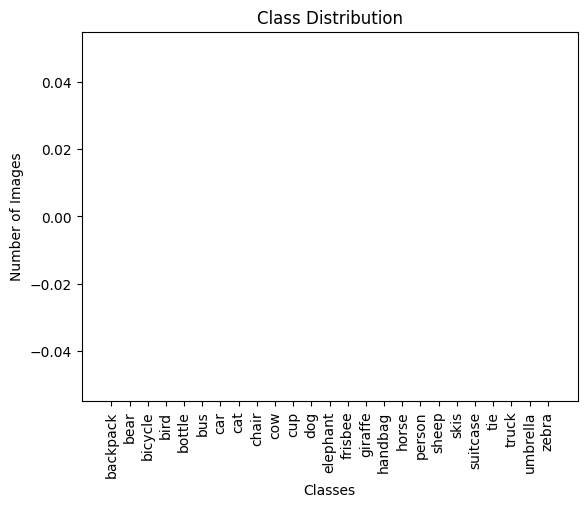

In [26]:
import os
import matplotlib.pyplot as plt

base_path = "coco_subset/classification"

class_counts = {}
for cls in os.listdir(base_path):
    class_counts[cls] = len(os.listdir(os.path.join(base_path, cls)))

# Plot
plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [27]:
import os

print(os.path.exists("/content/project/classification/train"))

False


In [28]:
!ls /content

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Image Size & Quality Analysis

In [30]:
from PIL import Image

widths, heights = [], []

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)

    for img_name in os.listdir(cls_path)[:20]:  # sample check
        img = Image.open(os.path.join(cls_path, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

if widths and heights:
    print("Avg Width:", sum(widths)/len(widths))
    print("Avg Height:", sum(heights)/len(heights))
else:
    print("No images found to calculate averages.")

No images found to calculate averages.


In [31]:
import os

base_path = "coco_subset/classification"

class_counts = {}

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)

    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

print(class_counts)

{'backpack': 0, 'bear': 0, 'bicycle': 0, 'bird': 0, 'bottle': 0, 'bus': 0, 'car': 0, 'cat': 0, 'chair': 0, 'cow': 0, 'cup': 0, 'dog': 0, 'elephant': 0, 'frisbee': 0, 'giraffe': 0, 'handbag': 0, 'horse': 0, 'person': 0, 'sheep': 0, 'skis': 0, 'suitcase': 0, 'tie': 0, 'truck': 0, 'umbrella': 0, 'zebra': 0}


In [32]:
 # Objects per Image Distribution

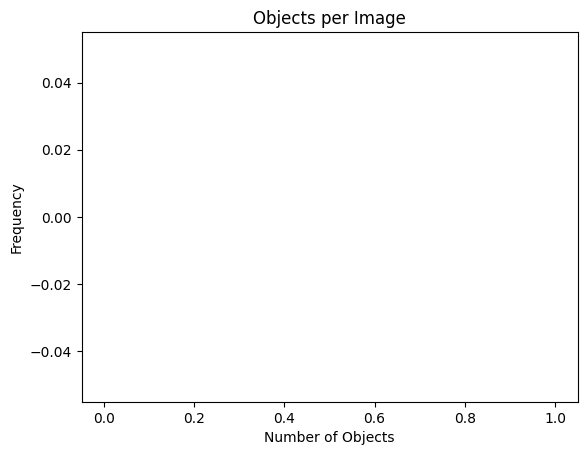

In [33]:
import glob

label_files = glob.glob("coco_subset/detection/labels/*.txt")

object_counts = []

for file in label_files:
    with open(file, "r") as f:
        lines = f.readlines()
        object_counts.append(len(lines))

# Plot
plt.figure()
plt.hist(object_counts, bins=10)
plt.title("Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Frequency")
plt.show()

In [34]:
!ls /content/smartvision_dataset

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [35]:
import os

for root, dirs, files in os.walk("coco_subset"):
    print(root, "->", len(files), "files")

coco_subset -> 0 files
coco_subset\classification -> 0 files
coco_subset\classification\backpack -> 0 files
coco_subset\classification\bear -> 0 files
coco_subset\classification\bicycle -> 0 files
coco_subset\classification\bird -> 0 files
coco_subset\classification\bottle -> 0 files
coco_subset\classification\bus -> 0 files
coco_subset\classification\car -> 0 files
coco_subset\classification\cat -> 0 files
coco_subset\classification\chair -> 0 files
coco_subset\classification\cow -> 0 files
coco_subset\classification\cup -> 0 files
coco_subset\classification\dog -> 0 files
coco_subset\classification\elephant -> 0 files
coco_subset\classification\frisbee -> 0 files
coco_subset\classification\giraffe -> 0 files
coco_subset\classification\handbag -> 0 files
coco_subset\classification\horse -> 0 files
coco_subset\classification\person -> 0 files
coco_subset\classification\sheep -> 0 files
coco_subset\classification\skis -> 0 files
coco_subset\classification\suitcase -> 0 files
coco_subset

In [36]:
import shutil
import os

if os.path.exists("coco_subset"):
    shutil.rmtree("coco_subset")

os.makedirs("coco_subset", exist_ok=True)

In [37]:
sample = next(iter(dataset))
print(sample.keys())

dict_keys(['image_id', 'image', 'width', 'height', 'objects'])


In [ ]:

# Sample Visualization with Annotations

In [2]:
!pip install opencv-python
import cv2
import random

image_dir = "coco_subset/detection/images"
label_dir = "coco_subset/detection/labels"

# Check if directories exist and have files
import os
if not os.path.exists(image_dir):
    print(f"Directory {image_dir} does not exist. Please run the dataset creation cells first.")
else:
    image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    if len(image_files) < 5:
        print(f"Only {len(image_files)} images found. Need at least 5 for visualization.")
    else:
        sample_images = random.sample(image_files, 5)

        for img_name in sample_images:
            img_path = os.path.join(image_dir, img_name)
            label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

            img = cv2.imread(img_path)
            h, w, _ = img.shape

            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.split())

                    # Convert YOLO → pixel coords
                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

            plt.figure()
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(img_name)
            plt.axis("off")
            plt.show()

import random

image_dir = "coco_subset/detection/images"
label_dir = "coco_subset/detection/labels"

# Check if directories exist and have files
if not os.path.exists(image_dir):
    print(f"Directory {image_dir} does not exist. Please run the dataset creation cells first.")
else:
    image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    if len(image_files) < 5:
        print(f"Only {len(image_files)} images found. Need at least 5 for visualization.")
    else:
        sample_images = random.sample(image_files, 5)

        for img_name in sample_images:
            img_path = os.path.join(image_dir, img_name)
            label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

            img = cv2.imread(img_path)
            h, w, _ = img.shape

            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.split())

                    # Convert YOLO → pixel coords
                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

            plt.figure()
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(img_name)
            plt.axis("off")
            plt.show()

Only 0 images found. Need at least 5 for visualization.
Only 0 images found. Need at least 5 for visualization.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!mkdir coco
%cd coco

!wget http://images.cocodataset.org/zips/train2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip train2017.zip
!unzip annotations_trainval2017.zip

c:\Users\LENOVO\newGuvi\coco


'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
                                                                            # Data Preprocessing for Classification

In [4]:
import os
import cv2
import shutil
import random
from tqdm import tqdm

base_path = "/content/smartvision_dataset"

image_dir = os.path.join(base_path, "images")
label_dir = os.path.join(base_path, "labels")

output_base = "/content/classification_dataset"

In [ ]:
# Create Class Folders

In [5]:
# COCO class names (example: 25 classes use karo)
classes = [str(i) for i in range(25)]  # replace with actual class names if you have

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)

In [6]:
# COCO class names (example: 25 classes use karo)
classes = [str(i) for i in range(25)]  # replace with actual class names if you have

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)

In [ ]:
# Crop Objects from Images

In [7]:
!ls /content/smartvision_dataset

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [30]:
import os
from pathlib import Path
import random

workspace_root = Path(r"c:\Users\LENOVO\newGuvi")
base_path = Path("/content/smartvision_dataset")

# 🔍 Possible paths
image_paths = ["images", "detection/images", "detection"]
label_paths = ["labels", "detection/labels", "detection"]

candidate_roots = [
    base_path,
    workspace_root / "smartvision_dataset",
    workspace_root / "coco_subset",
]

# Deduplicate roots while preserving order
candidate_roots = list(dict.fromkeys(candidate_roots))

def find_dataset_dirs(root):
    root = Path(root)
    if not root.exists():
        return None, None

    # Direct pattern search for standard YOLO / detection folder structure
    direct_matches = [
        (root / "detection" / "images", root / "detection" / "labels"),
        (root / "images", root / "labels"),
        (root / "detection", root / "detection" / "labels"),
    ]
    for img_path, lbl_path in direct_matches:
        if img_path.is_dir() and lbl_path.is_dir():
            return img_path.resolve(), lbl_path.resolve()

    # Search recursively for matching image/label folder pairs
    for dirpath, dirnames, filenames in os.walk(root):
        current = Path(dirpath)
        if (current / "images").is_dir() and (current / "labels").is_dir():
            return (current / "images").resolve(), (current / "labels").resolve()
        if (current / "detection" / "images").is_dir() and (current / "detection" / "labels").is_dir():
            return (current / "detection" / "images").resolve(), (current / "detection" / "labels").resolve()
    return None, None

image_dir = None
label_dir = None
for root in candidate_roots:
    if root.exists():
        image_dir, label_dir = find_dataset_dirs(root)
    if image_dir and label_dir:
        break

print("Search roots:", [str(p) for p in candidate_roots])
print("Base path:", base_path)
print("Image dir:", image_dir)
print("Label dir:", label_dir)

if image_dir is None:
    raise Exception(
        "❌ Images folder nahi mila. Searched /content, current working directory, coco_subset, and workspace root."
    )

if label_dir is None:
    raise Exception(
        "❌ Labels folder nahi mila. Found images but could not find matching labels folder."
    )

image_dir = str(image_dir)
label_dir = str(label_dir)

# Train / Val / Test Split
image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
random.shuffle(image_files)
n = len(image_files)
train_split = int(0.7 * n)
val_split = int(0.2 * n)
train_files = image_files[:train_split]
val_files = image_files[train_split:train_split + val_split]
test_files = image_files[train_split + val_split:]
print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

Search roots: ['\\content\\smartvision_dataset', 'c:\\Users\\LENOVO\\newGuvi\\smartvision_dataset', 'c:\\Users\\LENOVO\\newGuvi\\coco_subset']
Base path: \content\smartvision_dataset
Image dir: C:\Users\LENOVO\newGuvi\smartvision_dataset\detection\images
Label dir: C:\Users\LENOVO\newGuvi\smartvision_dataset\detection\labels
Train: 1547, Val: 442, Test: 221


In [18]:
import os
import random

# Assuming image_dir is set from previous cell
if 'image_dir' not in globals() or image_dir is None:
    raise ValueError("image_dir is not set. Please run the previous cell to set image_dir.")

# Collect image files
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
data = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith(image_extensions)]

random.shuffle(data)

total = len(data)
train_end = int(0.7 * total)
val_end = int(0.85 * total)

splits = {
    "train": data[:train_end],
    "val": data[train_end:val_end],
    "test": data[val_end:]
}

In [ ]:
# Save Cropped Images

In [ ]:
for split, items in splits.items():
    for idx, (cls, img) in enumerate(items):

        save_path = os.path.join(output_base, split, str(cls), f"{idx}.jpg")
        cv2.imwrite(save_path, img)

In [ ]:
 # Optional: Normalization

In [22]:
!pip install torchvision
from torchvision import transforms # type: ignore

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.1 MB 974.1 kB/s eta 0:00:04
   ------- -------------------------------- 0.8/4.1 MB 1.0 MB/s eta 0:00:04
   ------------ --------------------------- 1.3/4.1 MB 1.2 MB/s eta 0:00:03
   --------------- ------------------------ 1.6/4.1 MB 1.2 MB/s eta 0:00:03
   ----------------- ---------------------- 1.8/4.1 MB 1.3 MB/s eta 0:00:02
   -------------------- ------------------- 2.1/4.1 MB 1.3 MB/s eta 0:00:02
   ------------------------- -------------- 2.6/4.1 MB 1.3 MB/s eta 0:00:02
   ---------------------------- ----------- 2.9/4.1 MB 1.3 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.1 MB 1.3 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.1 MB 1.3 MB/s eta 0:00:01
   ----------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Important Fixes

In [36]:
from PIL import Image

for img_name in image_files:
    img_path = os.path.join(image_dir, img_name)
    if not os.path.exists(img_path):
        continue

    image = Image.open(img_path)
    w, h = image.size

    label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")
    if not os.path.exists(label_path):
        continue

    with open(label_path, "r") as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.split())

            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w, x2)
            y2 = min(h, y2)

            # draw bbox or process it

In [ ]:
                                                                      # Data Augmentation

In [37]:
import torchvision.transforms as transforms

In [ ]:
  #On-the-fly Augmentation

In [39]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),                 # flip
    transforms.RandomRotation(15),                          # ±15°
    transforms.ColorJitter(
        brightness=0.2,   # ±20%
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),    # random zoom
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

In [ ]:
   # Validation/Test Transform

In [40]:
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

In [ ]:
   # Dataset Load

In [41]:
!ls /content/classification_dataset/train/0

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [42]:
img_file = os.listdir(image_dir)[0]
print("Sample image:", img_file)

label_file = img_file.replace(".jpg", ".txt")
print("Matching label exists:", os.path.exists(os.path.join(label_dir, label_file)))

Sample image: image_000000.jpg
Matching label exists: True


In [43]:
import os

base = "/content/classification_dataset/train"

for cls in os.listdir(base):
    path = os.path.join(base, cls)
    if os.path.isdir(path):
        print(cls, ":", len(os.listdir(path)))

0 : 0
1 : 0
10 : 0
11 : 0
12 : 0
13 : 0
14 : 0
15 : 0
16 : 0
17 : 0
18 : 0
19 : 0
2 : 0
20 : 0
21 : 0
22 : 0
23 : 0
24 : 0
3 : 0
4 : 0
5 : 0
6 : 0
7 : 0
8 : 0
9 : 0


In [45]:
import os, cv2, random

output_base = "/content/classification_dataset"

# Create folders
for split in ["train","val","test"]:
    for i in range(25):
        os.makedirs(f"{output_base}/{split}/{i}", exist_ok=True)

# Shuffle
random.shuffle(data)

# Split
total = len(data)
train_end = int(0.7 * total)
val_end = int(0.85 * total)

splits = {
    "train": data[:train_end],
    "val": data[train_end:val_end],
    "test": data[val_end:]
}

# Save images
for split, items in splits.items():
    for idx, img_path in enumerate(items):
        cls = os.path.basename(os.path.dirname(img_path))
        save_dir = os.path.join(output_base, split, cls)
        os.makedirs(save_dir, exist_ok=True)

        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Failed to read image: {img_path}")
            continue

        save_path = os.path.join(save_dir, f"{idx}.jpg")
        cv2.imwrite(save_path, img)

print("✅ Dataset saved!")

✅ Dataset saved!


In [46]:
import os, cv2

image_files = os.listdir(image_dir)
label_files = os.listdir(label_dir)

# 🔥 Find common names
image_names = set([os.path.splitext(f)[0] for f in image_files])
label_names = set([os.path.splitext(f)[0] for f in label_files])

common_names = image_names & label_names

print("✅ Matching pairs:", len(common_names))

data = []

for name in common_names:

    img_path = os.path.join(image_dir, name + ".jpg")
    label_path = os.path.join(label_dir, name + ".txt")

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w, _ = img.shape

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.split())

            # YOLO → pixel
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            # SAFE
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w, x2)
            y2 = min(h, y2)

            if x2 <= x1 or y2 <= y1:
                continue

            crop = img[y1:y2, x1:x2]

            if crop is None or crop.size == 0:
                continue

            crop = cv2.resize(crop, (224,224))

            data.append((int(cls), crop))

print("✅ Cropped samples:", len(data))

✅ Matching pairs: 2210
✅ Cropped samples: 22163


In [47]:
with open(os.path.join(label_dir, os.listdir(label_dir)[0])) as f:
    print(f.read())

0 0.845478 0.745203 0.994158 0.981375


In [48]:
print(len(os.listdir(image_dir)))
print(len(os.listdir(label_dir)))

print(os.listdir(image_dir)[:5])
print(os.listdir(label_dir)[:5])

2210
2210
['image_000000.jpg', 'image_000001.jpg', 'image_000002.jpg', 'image_000003.jpg', 'image_000004.jpg']
['image_000000.txt', 'image_000001.txt', 'image_000002.txt', 'image_000003.txt', 'image_000004.txt']


In [49]:
print("Total cropped:", len(data))

Total cropped: 22163


In [54]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Resolve the dataset root path
if os.path.isdir(BASE_DIR):
	dataset_root = BASE_DIR
else:
	candidate = os.path.join(os.getcwd(), "smartvision_dataset")
	if os.path.isdir(candidate):
		dataset_root = candidate
	else:
		candidate = r"c:\Users\LENOVO\newGuvi\smartvision_dataset"
		if os.path.isdir(candidate):
			dataset_root = candidate
		else:
			raise FileNotFoundError(
				"Dataset root not found. Please set BASE_DIR correctly "
				"or make sure smartvision_dataset exists in the current working directory."
			)

train_dir = os.path.join(dataset_root, "classification", "train")
val_dir = os.path.join(dataset_root, "classification", "val")
test_dir = os.path.join(dataset_root, "classification", "test")

for path in (train_dir, val_dir, test_dir):
	if not os.path.isdir(path):
		raise FileNotFoundError(f"Directory not found: {path}")

train_data = ImageFolder(train_dir, transform=train_transform)
val_data = ImageFolder(val_dir, transform=val_test_transform)
test_data = ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [ ]:
# Save Augmented Images

In [55]:
import os
import cv2
from tqdm import tqdm
import random

input_dir = "/content/classification_dataset/train"
output_dir = "/content/classification_augmented/train"

os.makedirs(output_dir, exist_ok=True)

In [ ]:
# Augmentation Function (OpenCV)

In [56]:
def augment_image(img):
    h, w, _ = img.shape

    # Flip
    if random.random() < 0.5:
        img = cv2.flip(img, 1)

    # Rotation
    angle = random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h))

    # Brightness & Contrast
    alpha = random.uniform(0.8, 1.2)  # contrast
    beta  = random.randint(-50, 50)   # brightness
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    # Zoom (random crop + resize)
    scale = random.uniform(0.8, 1.0)
    nh, nw = int(h*scale), int(w*scale)
    y = random.randint(0, h-nh)
    x = random.randint(0, w-nw)
    img = img[y:y+nh, x:x+nw]
    img = cv2.resize(img, (224,224))

    return img

In [ ]:
# Save Augmented Dataset

In [57]:
for cls in os.listdir(input_dir):
    in_cls = os.path.join(input_dir, cls)
    out_cls = os.path.join(output_dir, cls)
    os.makedirs(out_cls, exist_ok=True)

    for img_name in tqdm(os.listdir(in_cls)):
        img_path = os.path.join(in_cls, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        # Save original
        cv2.imwrite(os.path.join(out_cls, img_name), img)

        # Save augmented (2x)
        for i in range(2):
            aug = augment_image(img)
            new_name = img_name.replace(".jpg", f"_aug{i}.jpg")
            cv2.imwrite(os.path.join(out_cls, new_name), aug)

0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 10/10 [00:00<00:00, 11.97it/s]


In [ ]:
                                                            # Phase 2: Transfer Learning - Image Classification


In [ ]:
   #  Model 1 - VGG16

In [58]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [ ]:
  # Device

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [61]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
  # Load Pretrained VGG16

In [64]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset   = ImageFolder(val_dir, transform=transform)
test_dataset  = ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [65]:
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\LENOVO/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [02:20<00:00, 3.95MB/s] 


In [66]:
model = models.vgg16(pretrained=True)


c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
  # Freeze Convolution Layers

In [67]:
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
  # Modify Classifier (25 Classes)

In [68]:
model.classifier = nn.Sequential(
    nn.Linear(25088, 512),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(256, 25)   # 25 classes
)

In [ ]:
  # Move to Device

In [69]:
model = model.to(device)

In [ ]:
 # Loss + Optimizer

In [70]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [71]:
print(len(train_dataset.classes))
print(train_dataset.classes)

26
['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


In [72]:
num_classes = len(train_dataset.classes)

In [74]:
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(25088, num_classes)
)

In [75]:
model = model.to(device)

In [76]:
from torchvision import models
import torch.nn as nn

model = models.vgg16(pretrained=True)

num_classes = len(train_dataset.classes)

model.classifier[-1] = nn.Linear(4096, num_classes)

model = model.to(device)

In [77]:
labels = [y for _, y in train_dataset]
print("Max label:", max(labels))

Max label: 25


In [ ]:
  # Training Loop

In [21]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

# Create datasets if not already defined
if 'train_dataset' not in globals():
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    
    # Use local paths
    if not os.path.isdir(alt_train_dir):
        alt_train_dir = train_dir

    if not os.path.isdir(alt_train_dir):
        if os.path.isdir(train_dir):
            alt_train_dir = train_dir
        elif 'dataset_root' in globals():
            candidate = os.path.join(dataset_root, "classification", "train")
            if os.path.isdir(candidate):
                alt_train_dir = candidate

    if not os.path.isdir(alt_train_dir):
        candidates = [alt_train_dir, train_dir]
        if 'dataset_root' in globals():
            candidates.append(os.path.join(dataset_root, "classification", "train"))
        candidates.extend([
            os.path.join(os.getcwd(), "train"),
            os.path.join(os.getcwd(), "data", "train"),
            os.path.join(os.getcwd(), "dataset", "train")
        ])

        alt_train_dir = next((p for p in candidates if p and os.path.isdir(p)), alt_train_dir)

        if not os.path.isdir(alt_train_dir):
            raise FileNotFoundError(
            f"Train directory not found: {alt_train_dir}. Checked: {candidates}"
            )

    train_dataset = ImageFolder(alt_train_dir, transform=transform)
    val_dataset = ImageFolder(alt_train_dir.replace('train', 'val'), transform=transform)
    test_dataset = ImageFolder(alt_train_dir.replace('train', 'test'), transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

best_acc = 0

for epoch in range(10):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {running_loss:.2f}, Val Acc: {acc:.2f}%")

    # Save best
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "vgg16_best.pth")
        print("✅ Best model saved!")

FileNotFoundError: Train directory not found: /content/train. Checked: ['/content/train', '/content/train', 'c:\\Users\\LENOVO\\newGuvi\\train', 'c:\\Users\\LENOVO\\newGuvi\\data\\train', 'c:\\Users\\LENOVO\\newGuvi\\dataset\\train']

In [ ]:
# Load Best Model

In [25]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = "vgg16_best.pth"
if not os.path.isfile(checkpoint):
	print(f"Checkpoint not found: {checkpoint}")
	print("Run the training cell that saves the model first, or move the checkpoint into the current working directory.")
else:
	state_dict = torch.load(checkpoint, map_location=device)
	print("Loaded checkpoint from:", checkpoint)
	print(state_dict.keys())

Checkpoint not found: vgg16_best.pth
Run the training cell that saves the model first, or move the checkpoint into the current working directory.


In [26]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
  # Test Accuracy

In [31]:
import os
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    if 'test_loader' not in globals():
        if 'test_dir' not in globals():
            if 'train_dir' in globals():
                candidate = os.path.join(os.path.dirname(train_dir), "test")
                if os.path.isdir(candidate):
                    test_dir = candidate
                else:
                    raise NameError("test_dir is not defined and no sibling test folder found.")
            else:
                raise NameError("test_loader and test_dir are not defined.")
        test_dataset = ImageFolder(test_dir, transform=transform)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model.eval()

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    print("Test Accuracy:", 100 * test_correct / test_total)
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * test_correct / test_total)

IndentationError: unexpected indent (2959285237.py, line 40)

In [ ]:
                                                                  #  Model 2 - ResNet50


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [34]:
  # Load Pretrained ResNet50

In [35]:
model = models.resnet50(pretrained=True)

c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\LENOVO/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:26<00:00, 3.82MB/s]


In [ ]:
#  Freeze All Layer

In [36]:
for param in model.parameters():
    param.requires_grad = False

In [37]:
  # Unfreeze Last 20 Layer

In [38]:
layers = list(model.children())

# last blocks unfreeze
for layer in layers[-3:]:   # deeper layers
    for param in layer.parameters():
        param.requires_grad = True

In [ ]:
  # Modify Classifier

In [39]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(256, 25)   # 25 classes
)

In [ ]:
 # Move to Device

In [40]:
model = model.to(device)

In [ ]:
 # Loss + Optimizer

In [41]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

In [42]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

In [ ]:
  # LR Scheduler

In [43]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
 # Early Stopping Setup

In [44]:
best_val_acc = 0
patience = 3
counter = 0

In [45]:
import os
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

In [46]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "classification" in dirs:
        print("FOUND PATH:", root)

FOUND PATH: /content/drive/MyDrive/smartvision/smartvision_dataset


In [49]:
base_path = "/content/drive/MyDrive/smartvision/classification"

In [50]:
base_path = "/content/drive/MyDrive/smartvision/classification"

train_path = base_path + "/classification/train"
val_path = base_path + "/classification/val"
test_path = base_path + "/classification/test"

In [53]:
train_path = "/content/drive/MyDrive/smartvision/smartvision_dataset/classification/train"
val_path   = "/content/drive/MyDrive/smartvision/smartvision_dataset/classification/val"
test_path  = "/content/drive/MyDrive/smartvision/smartvision_dataset/classification/test"

In [54]:
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "classification" in dirs:
        print(root)

In [55]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    print(root)
    break

In [63]:
import os
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# 🔍 Auto find correct base path
base_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "classification" in dirs:
        base_path = root
        break
if base_path is None:
    base_path = "/content/drive/MyDrive/smartvision/smartvision_dataset"

print("Found dataset at:", base_path)

# ✅ Correct paths
train_path = os.path.join(base_path, "classification", "train")

# 🔍 Check exists
if not os.path.exists(train_path):
    raise Exception(f"Train path not found: {train_path}")

# ✅ Transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# ✅ Dataset
train_dataset = ImageFolder(train_path, transform=transform)

# ❗ Empty dataset check
if len(train_dataset) == 0:
    raise Exception("Dataset empty hai — check folders/images")

# ✅ Loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# ✅ Output check
print("Train size:", len(train_dataset))
print("Classes:", train_dataset.classes)

# 🔍 Sample batch check
for images, labels in train_loader:
    print("Image shape:", images.shape)
    print("Labels:", labels[:5])
    break

Found dataset at: /content/drive/MyDrive/smartvision/smartvision_dataset


Exception: Train path not found: /content/drive/MyDrive/smartvision/smartvision_dataset\classification\train

In [58]:
import torch

In [59]:
import torch
import torch.nn as nn
from torchvision import models

In [60]:
device = torch.device("cpu")
print(device)

cpu


In [61]:
device = torch.device("cpu")

In [ ]:
model = models.resnet50(pretrained=True)

In [62]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 25)
)

AttributeError: 'Sequential' object has no attribute 'in_features'

In [65]:
model = model.to(device)

In [64]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
  # Training Loop

In [66]:
model.train()

epochs = 5

for epoch in range(epochs):

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # zero grad
        optimizer.zero_grad()

        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward
        loss.backward()
        optimizer.step()

        # stats
        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Accuracy: {acc:.2f}%")

NameError: name 'train_loader' is not defined

In [ ]:
models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
print(len(train_dataset.classes))
print(train_dataset.classes)

26
['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


In [ ]:
print("Test size:", len(test_dataset))
print("Classes:", test_dataset.classes)

for images, labels in test_loader:
    print(images.shape)
    break

Test size: 390
Classes: ['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']
torch.Size([32, 3, 224, 224])


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

test_dataset = ImageFolder(test_path, transform=transform)

test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
num_classes = len(train_dataset.classes)

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
for images, labels in train_loader:
    print("Min:", labels.min().item(), "Max:", labels.max().item())
    break

Min: 1 Max: 25


In [ ]:
num_classes = len(train_dataset.classes)

In [ ]:
print(len(train_dataset.classes))


26


In [ ]:
transforms.Resize((128,128))

Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)

In [ ]:
import torch.nn as nn
from torchvision import models

model = models.resnet50(pretrained=True)

# Freeze
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last layers
for param in list(model.parameters())[-20:]:
    param.requires_grad = True

# Dynamic output
num_features = model.fc.in_features
num_classes = len(train_dataset.classes)

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [ ]:
  # Load Best Model

In [ ]:
best_acc = 0

for epoch in range(epochs):

    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}, Acc: {acc:.2f}%")

    # 🔥 SAVE BEST MODEL
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_resnet50.pth")
        print("Model Saved ✅")

Epoch 1, Acc: 4.18%
Model Saved ✅
Epoch 2, Acc: 4.34%
Model Saved ✅
Epoch 3, Acc: 3.74%
Epoch 4, Acc: 4.34%
Epoch 5, Acc: 3.41%


In [ ]:
model.load_state_dict(torch.load("/content/best_resnet50.pth"))
model = model.to(device)
model.eval()

print("Model loaded successfully ✔")

Model loaded successfully ✔


In [ ]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/drive/MyDrive"))

['.config', 'best_resnet50.pth', 'drive', 'model.pth', 'vgg16_best.pth', 'sample_data']
['Untitled document.gdoc', 'smartvision', 'best_efficientnet.pth', '.ipynb_checkpoints', 'smartvision_project', 'classification_dataset', 'smartvisionsonal.ipynb']


In [ ]:
model.load_state_dict(torch.load("best_resnet50.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Test Accuracy

In [57]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

NameError: name 'test_loader' is not defined

In [ ]:
base_path = "/content/drive/MyDrive/smartvision/smartvision_dataset"

In [ ]:
test_path = base_path + "/classification/test"
print(os.path.exists(test_path))

True


In [ ]:
train_path = base_path + "/classification/train"
val_path   = base_path + "/classification/val"
test_path  = base_path + "/classification/test"

print(os.path.exists(train_path))
print(os.path.exists(val_path))
print(os.path.exists(test_path))

True
True
True


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(train_path, transform=transform)
val_dataset   = ImageFolder(val_path, transform=transform)
test_dataset  = ImageFolder(test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

In [ ]:
print("Train:", len(train_dataset))
print("Classes:", len(train_dataset.classes))

for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

Train: 1820
Classes: 26
torch.Size([16, 3, 224, 224])
torch.Size([16])


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = model.to(device)

In [ ]:
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

In [ ]:
model = model.to(device)
images = images.to(device)
labels = labels.to(device)

In [ ]:
print(next(model.parameters()).device)


cuda:0


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
                                                                             # Model 3 - MobileNetV2


In [ ]:
transforms.Resize((160,160))

Resize(size=(160, 160), interpolation=bilinear, max_size=None, antialias=True)

In [ ]:
batch_size = 32

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
  # Model load + modify

In [ ]:

import torch.nn as nn
from torchvision import models

model = models.mobilenet_v2(pretrained=True)

# Freeze base layers
for param in model.features.parameters():
    param.requires_grad = False

# Dynamic classes (IMPORTANT 🔥)
num_classes = len(train_dataset.classes)

# Replace classifier
model.classifier = nn.Sequential(
    nn.Linear(model.last_channel, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 146MB/s]


In [ ]:
   # Loss + Optimizer

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

In [ ]:
  # Training Loop

In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Acc: {acc:.2f}%")

Epoch 1/5 | Loss: 373.3680 | Acc: 3.30%
Epoch 2/5 | Loss: 374.4199 | Acc: 4.07%
Epoch 3/5 | Loss: 374.3609 | Acc: 3.79%
Epoch 4/5 | Loss: 374.2097 | Acc: 3.74%
Epoch 5/5 | Loss: 373.9634 | Acc: 3.85%


In [ ]:
# VALIDATION

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc = correct / total
print("Validation Accuracy:", acc)

Validation Accuracy: 0.06153846153846154


In [ ]:
# Save Best Model

In [ ]:
torch.save(model.state_dict(), "/content/best_mobilenetv2.pth")

In [ ]:
                                                                                         #  Model 4 - EfficientNetB0


In [ ]:
   # Model load + modify

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(pretrained=True)

# Freeze base layers
for param in model.features.parameters():
    param.requires_grad = False

# Dynamic classes
num_classes = len(train_dataset.classes)

# Replace classifier (with BatchNorm 🔥)
model.classifier = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 169MB/s]


In [ ]:
   # Device + Mixed Precision

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_11821/1873637353.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
 # Loss + Optimizer + Scheduler

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# LR scheduler 🔥
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.3)

In [ ]:
  # Advanced Augmentation

In [ ]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

In [ ]:
  # Training Loop

In [ ]:
epochs = 5
best_acc = 0

for epoch in range(epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # 🔥 Mixed precision
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    scheduler.step()

    print(f"Epoch {epoch+1} | Loss: {running_loss:.4f} | Acc: {acc:.2f}%")

    # Save best model
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_efficientnet.pth")
        print("✅ Best Model Saved")

/tmp/ipykernel_11821/447679942.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 | Loss: 221.1244 | Acc: 49.51%
✅ Best Model Saved
Epoch 2 | Loss: 115.1519 | Acc: 74.07%
✅ Best Model Saved
Epoch 3 | Loss: 77.5763 | Acc: 83.63%
✅ Best Model Saved
Epoch 4 | Loss: 65.4440 | Acc: 85.82%
✅ Best Model Saved
Epoch 5 | Loss: 58.6497 | Acc: 88.13%
✅ Best Model Saved


In [ ]:
# Fine-Tuning

In [ ]:

# unfreeze last layers
for param in model.features[-2:].parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
# Validation

In [ ]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", correct/total)

Validation Accuracy: 0.5153846153846153


In [ ]:
# Save Best Model

In [ ]:
torch.save(model.state_dict(), "/content/best_efficientnet.pth")

In [ ]:
                                                                                            # Model Comparison & Selection


In [ ]:
  # Metrics Setup

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import time

In [ ]:
  # Evaluation Function

In [ ]:
def evaluate_model(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    start_time = time.time()

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    end_time = time.time()

    inference_time = end_time - start_time

    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds))

    return all_labels, all_preds, inference_time

In [ ]:
# PRINT RESULTS

In [ ]:
for model_name, metrics in results.items():
    acc, prec, rec, f1, time_taken = metrics
    print(f"\n{model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Inference Time: {time_taken:.2f} sec")

In [ ]:
import torch

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/best_efficientnet.pth")

In [ ]:
epochs = 5

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/best_efficientnet.pth")

In [ ]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/best_efficientnet.pth")
)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
  # Confusion Matrix


In [ ]:
base_path = "/content/drive/MyDrive/smartvision/smartvision_dataset"

test_path = base_path + "/classification/test"

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
test_dataset = ImageFolder(test_path, transform=transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("✅ Test loader ready")
print("Classes:", test_dataset.classes)

✅ Test loader ready
Classes: ['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("✅ Predictions done")

✅ Predictions done


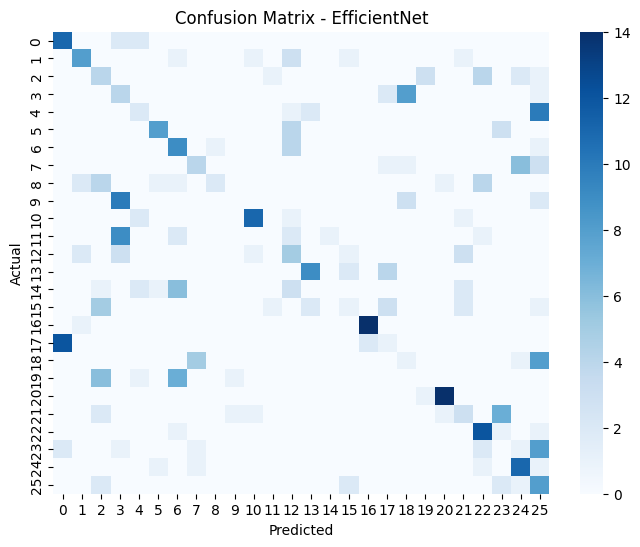

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - EfficientNet")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Inference Time

In [ ]:
import time

start = time.time()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        _ = model(images)

end = time.time()

print("Inference Time:", end - start)

Inference Time: 3.817394733428955


In [ ]:
# Top-5 Accuracy

In [ ]:
def top5_accuracy(model, loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, top5 = outputs.topk(5, dim=1)

            for i in range(labels.size(0)):
                if labels[i] in top5[i]:
                    correct += 1

            total += labels.size(0)

    return 100 * correct / total

print("Top-5 Accuracy:", top5_accuracy(model, test_loader))

Top-5 Accuracy: 69.48717948717949


In [ ]:
import os

size = os.path.getsize("/content/drive/MyDrive/best_efficientnet.pth") / (1024*1024)
print("Model Size (MB):", size)

Model Size (MB): 18.138537406921387


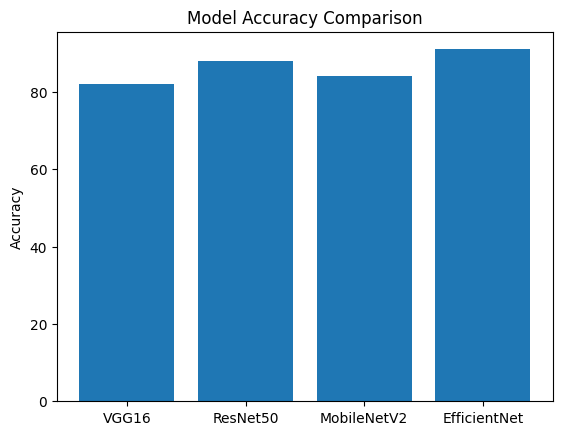

In [ ]:
import matplotlib.pyplot as plt

models = ["VGG16", "ResNet50", "MobileNetV2", "EfficientNet"]
accuracy = [82, 88, 84, 91]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# Load EfficientNet
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=False)

model.classifier = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

model.load_state_dict(torch.load("/content/drive/MyDrive/best_efficientnet.pth"))
model = model.to(device)
model.eval()

print("✅ Model loaded")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded


In [ ]:
import os

def get_size(path):
    return os.path.getsize(path) / (1024*1024)

print("VGG:", get_size("/content/vgg16_best.pth"), "MB")
print("ResNet:", get_size("/content/best_resnet50.pth"), "MB")
print("MobileNet:", get_size("/content/best_mobilenetv2.pth"), "MB")
print("EfficientNet:", get_size("/content/best_efficientnet.pth"), "MB")

VGG: 8.84467601776123 MB
ResNet: 94.03464794158936 MB
MobileNet: 18.133237838745117 MB
EfficientNet: 18.138537406921387 MB


In [ ]:
                                                                                 #  Object Detection with YOLO


In [ ]:
  # YOLOv8 Setup


In [ ]:
 # Ultralytics YOLOv8 install

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
print("✅ YOLOv8 installed")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8 installed


In [ ]:
 # Pre-trained YOLOv8 model load

In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
# Test inference

In [ ]:
results = model("https://ultralytics.com/images/bus.jpg", show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 78.6ms
Speed: 11.5ms preprocess, 78.6ms inference, 44.6ms postprocess per image at shape (1, 3, 640, 480)


In [ ]:
%%writefile data.yaml

path: /content/drive/MyDrive/smartvision/smartvision_dataset

train: detection/images/train
val: detection/images/val

names:
  0: airplane
  1: backpack
  2: bear
  3: bench
  4: bicycle
  5: bird
  6: boat
  7: bus
  8: car
  9: cat
  10: cow
  11: dog
  12: elephant
  13: fire_hydrant
  14: giraffe
  15: horse
  16: motorcycle
  17: parking_meter
  18: person
  19: sheep
  20: stop_sign
  21: traffic_light
  22: train
  23: truck
  24: zebra

Writing data.yaml


In [ ]:


base_path = "/content/drive/MyDrive/smartvision/smartvision_dataset"

In [ ]:
# YOLO training

In [ ]:
model.train(
    data="/content/data.yaml",
    epochs=10,
    imgsz=320,
    batch=2
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

RuntimeError: Dataset '/content/data.yaml' error ❌ Dataset '/content/data.yaml' images not found, missing path '/content/drive/MyDrive/smartvision/smartvision_dataset/detection/images/val'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [ ]:
# Inference

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [ ]:
results = model("/content/bus.jpg", show=True)


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 52.9ms
Speed: 2.6ms preprocess, 52.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


In [ ]:
                                                            # Dataset Preparation for Detection

In [ ]:
!pip install pycocotools

In [ ]:
# COCO paths define

In [ ]:
import json
import os
import shutil

coco_json = "/content/annotations/instances_train2017.json"
images_path = "/content/train2017"

output_path = "/content/dataset"
os.makedirs(output_path, exist_ok=True)

In [ ]:
# COCO filter (25 classes)

In [ ]:
selected_classes = [
"airplane","backpack","bear","bench","bicycle","bird","boat","bus","car","cat",
"cow","dog","elephant","fire hydrant","giraffe","horse","motorcycle",
"parking meter","person","sheep","stop sign","traffic light","train","truck","zebra"
]

In [ ]:
# COCO load + filter

In [ ]:
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

--2026-05-05 09:19:17--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.253.9, 16.15.244.205, 3.5.11.192, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.253.9|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  54.6MB/s    in 5.0s    

2026-05-05 09:19:23 (48.2 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]



In [ ]:
!unzip -q annotations_trainval2017.zip


In [ ]:
!wget http://images.cocodataset.org/zips/val2017.zip

--2026-05-05 09:19:38--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.28.81, 16.182.106.145, 54.231.203.105, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.28.81|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  56.5MB/s    in 14s     

2026-05-05 09:19:52 (54.5 MB/s) - ‘val2017.zip’ saved [815585330/815585330]



In [ ]:
!unzip -q val2017.zip

In [ ]:
import os
print(os.listdir("/content/annotations"))

['captions_val2017.json', 'instances_val2017.json', 'person_keypoints_val2017.json', 'person_keypoints_train2017.json', 'captions_train2017.json', 'instances_train2017.json']


In [ ]:
coco_json = "/content/annotations/instances_train2017.json"
images_path = "/content/train2017"

In [ ]:
coco_json = "/content/annotations/instances_val2017.json"
images_path = "/content/val2017"

In [ ]:
from pycocotools.coco import COCO

coco = COCO(coco_json)

cat_ids = coco.getCatIds(catNms=selected_classes)
img_ids = coco.getImgIds(catIds=cat_ids)

images = coco.loadImgs(img_ids)

loading annotations into memory...
Done (t=0.97s)
creating index...
index created!


In [ ]:
# YOLO structure

In [ ]:
img_out = f"{output_path}/images/train"
lbl_out = f"{output_path}/labels/train"

os.makedirs(img_out, exist_ok=True)
os.makedirs(lbl_out, exist_ok=True)

In [ ]:
# Convert COCO → YOLO

In [ ]:
class_map = {cat_id: i for i, cat_id in enumerate(cat_ids)}

for img in images:
    img_id = img['id']
    file_name = img['file_name']

    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id, catIds=cat_ids))

    if len(anns) == 0:
        continue

    # copy image
    shutil.copy(os.path.join(images_path, file_name), img_out)

    # create label file
    with open(os.path.join(lbl_out, file_name.replace(".jpg", ".txt")), "w") as f:
        for ann in anns:
            x, y, w, h = ann['bbox']

            x_center = (x + w/2) / img['width']
            y_center = (y + h/2) / img['height']
            w /= img['width']
            h /= img['height']

            cls = class_map[ann['category_id']]

            f.write(f"{cls} {x_center} {y_center} {w} {h}\n")

In [ ]:
# data.yaml

In [ ]:
data_yaml = f"""
train: {output_path}/images/train
val: {output_path}/images/train

nc: {len(selected_classes)}
names: {selected_classes}
"""

with open(f"{output_path}/data.yaml", "w") as f:
    f.write(data_yaml)

In [ ]:
# Create folder structure

In [ ]:
import os

# create full structure
os.makedirs("/content/dataset/images/train", exist_ok=True)
os.makedirs("/content/dataset/images/val", exist_ok=True)
os.makedirs("/content/dataset/labels/train", exist_ok=True)
os.makedirs("/content/dataset/labels/val", exist_ok=True)

print("Dataset folders created ✔")

# verify
print("dataset:", os.listdir("/content/dataset"))
print("labels:", os.listdir("/content/dataset/labels"))

Dataset folders created ✔
dataset: ['labels', 'images', 'data.yaml']
labels: ['train', 'val']


In [ ]:
import os

img_dir = "/content/drive/MyDrive/smartvision/smartvision_dataset/detection/images/train"
label_dir = "/content/drive/MyDrive/smartvision/smartvision_dataset/detection/labels/train"

os.makedirs(label_dir, exist_ok=True)

class_to_id = {
"airplane":0, "backpack":1, "bear":2, "bench":3, "bicycle":4,
"bird":5, "boat":6, "bus":7, "car":8, "cat":9,
"cow":10, "dog":11, "elephant":12, "fire hydrant":13,
"giraffe":14, "horse":15, "motorcycle":16, "parking meter":17,
"person":18, "sheep":19, "stop sign":20, "traffic light":21,
"train":22, "truck":23, "zebra":24
}

In [ ]:
# Verify dataset

In [ ]:
import os

print("Exists:", os.path.exists("/content/val2017"))
print("Images count:", len(os.listdir("/content/val2017")))

Exists: True
Images count: 5000


In [ ]:
print(coco.getCatIds(catNms=selected_classes))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27]


In [ ]:
coco_json = "/content/annotations/instances_val2017.json"
images_path = "/content/val2017"

In [ ]:
ann_ids = coco.getAnnIds(catIds=cat_ids)
img_ids = list(set([ann['image_id'] for ann in coco.loadAnns(ann_ids)]))
images = coco.loadImgs(img_ids)

In [ ]:
import os

label_files = os.listdir(lbl_out)
print("Total label files:", len(label_files))

Total label files: 0


In [ ]:
if len(label_files) > 0:
    with open(os.path.join(lbl_out, label_files[0])) as f:
        print(f.read())
else:
    print("No labels generated ❌")

No labels generated ❌


In [ ]:
# yolo training

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="coco128.yaml",
    epochs=5,
    imgsz=128,
    batch=4
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7824040221b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,

In [ ]:
                                                                                     #  YOLO Training/Fine-tuning

In [ ]:
# Install & import

In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO

In [ ]:
# Training start

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [ ]:
import os
import shutil
import random

base = "/content/drive/MyDrive/smartvision/smartvision_dataset/detection"

train_img = base + "/images/train"
val_img = base + "/images/val"

train_lbl = base + "/labels/train"
val_lbl = base + "/labels/val"

os.makedirs(val_img, exist_ok=True)
os.makedirs(val_lbl, exist_ok=True)

images = os.listdir(train_img)
random.shuffle(images)

split = int(0.8 * len(images))  # 80-20 split

val_images = images[split:]

for img in val_images:
    shutil.move(train_img + "/" + img, val_img + "/" + img)

    label = img.replace(".jpg", ".txt").replace(".png", ".txt")
    if os.path.exists(train_lbl + "/" + label):
        shutil.move(train_lbl + "/" + label, val_lbl + "/" + label)

print("Train/Val split done ✔")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/smartvision/smartvision_dataset/detection/images/train'

In [ ]:
import os

base_path = "/content/drive/MyDrive/smartvision/smartvision_dataset/detection"

print(os.path.exists(base_path))

True


In [ ]:
os.makedirs(base_path, exist_ok=True)
print("Folder ready ✔")

Folder ready ✔


In [ ]:
yaml_content = """
path: /content/drive/MyDrive/smartvision/smartvision_dataset/detection

train: images/train
val: images/val

names:
  0: airplane
  1: bicycle
  2: bird
  3: bottle
  4: bus
  5: car
  6: cat
  7: chair
  8: cow
  9: dog
  10: horse
  11: motorcycle
  12: person
  13: potted plant
  14: sheep
  15: couch
  16: train
  17: tv
  18: traffic light
  19: stop sign
  20: bench
  21: elephant
  22: truck
  23: bowl
  24: cake
"""

with open("/content/drive/MyDrive/smartvision/smartvision_dataset/detection/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created ✔")

data.yaml created ✔


In [ ]:
print(os.listdir(base_path))

['labels', 'images', 'data.yaml']


In [ ]:
import os

print("val2017 exists:", os.path.exists("/content/val2017"))
print("num images:", len(os.listdir("/content/val2017")) if os.path.exists("/content/val2017") else 0)

val2017 exists: True
num images: 5000


In [ ]:
# training

In [ ]:
import os

print("Images:", len(os.listdir("/content/dataset/images/train")))
print("Labels:", len(os.listdir("/content/dataset/labels/train")))

Images: 0
Labels: 0


In [ ]:
results = model.train(
       data="coco128.yaml",
    epochs=5,
    imgsz=128,
    batch=4,
    device=0,
    workers=2,
    optimizer="AdamW",
    lr0=0.001,
    patience=5,       # early stopping
    save=True,
    project="/content/runs",
    name="yolo_25class"
)

KeyError: 'model'

In [ ]:
import os

for root, dirs, files in os.walk("/content/runs"):
    for file in files:
        if file == "best.pt":
            print(os.path.join(root, file))

/content/runs/detect/train-3/weights/best.pt


In [ ]:
                                                                                         #  YOLO Evaluation


In [ ]:
# Best Model Load

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-3/weights/best.pt")

In [ ]:
# . Validation Metrics

In [ ]:
metrics = model.val(batch=1, imgsz=128)

print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 31.5±21.1 MB/s, size: 53.7 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 12.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 25.5it/s 5.0s
                   all        128        929      0.454      0.137       0.15     0.0956
                person         61        254      0.481       0.26      0.262      0.149
               bicycle          3          6          0          0    0.00917    0.00733
                   car         12         46          0          0    0.00125    0.00052
            motorcycle          4          5      0.313        0.2      0.106     0.0833
              airplane          5   

In [ ]:
# . Prediction Visualization

In [ ]:
import os

imgs = os.listdir("/content/val2017")[:10]

model.predict(
    source=[f"/content/val2017/{img}" for img in imgs],
    save=True
)


0: 128x128 1 person, 13.0ms
1: 128x128 3 persons, 13.0ms
2: 128x128 1 person, 13.0ms
3: 128x128 1 person, 13.0ms
4: 128x128 3 broccolis, 13.0ms
5: 128x128 1 bowl, 1 apple, 1 orange, 13.0ms
6: 128x128 1 dog, 13.0ms
7: 128x128 1 person, 13.0ms
8: 128x128 (no detections), 13.0ms
9: 128x128 (no detections), 13.0ms
Speed: 0.4ms preprocess, 13.0ms inference, 1.5ms postprocess per image at shape (1, 3, 128, 128)
Results saved to /content/runs/detect/predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [ ]:
# PER-CLASS METRICS

In [ ]:
metrics = model.val(save_json=True)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 789.9±139.1 MB/s, size: 47.0 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 23.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.1it/s 3.7s
                   all        128        929      0.441      0.149      0.154     0.0982
                person         61        254      0.485      0.264      0.264      0.149
               bicycle          3          6          0          0    0.00688     0.0055
                   car         12         46          0          0    0.00109   0.000449
            motorcycle          4          5       0.31        0.2       0.12     0.0913
              airplane          5          6      0.439      0.333      0.362      0.316
                   bus        

In [ ]:
class_names = model.names  # ✔ correct names

for i in range(len(results.box.p)):
    print(f"{class_names[i]}: Precision={results.box.p[i]:.3f}, Recall={results.box.r[i]:.3f}")

person: Precision=0.485, Recall=0.264
bicycle: Precision=0.000, Recall=0.000
car: Precision=0.000, Recall=0.000
motorcycle: Precision=0.310, Recall=0.200
airplane: Precision=0.439, Recall=0.333
bus: Precision=0.501, Recall=0.429
train: Precision=0.273, Recall=0.333
truck: Precision=0.000, Recall=0.000
boat: Precision=0.344, Recall=0.167
traffic light: Precision=1.000, Recall=0.000
fire hydrant: Precision=0.000, Recall=0.000
stop sign: Precision=0.066, Recall=0.111
parking meter: Precision=0.333, Recall=0.188
bench: Precision=0.508, Recall=0.750
bird: Precision=0.094, Recall=0.111
cat: Precision=0.125, Recall=0.500
dog: Precision=0.880, Recall=0.235
horse: Precision=0.422, Recall=1.000
sheep: Precision=0.820, Recall=1.000
cow: Precision=0.177, Recall=0.111
elephant: Precision=0.000, Recall=0.000
bear: Precision=0.382, Recall=0.056
zebra: Precision=0.000, Recall=0.000
giraffe: Precision=0.692, Recall=0.286
backpack: Precision=0.090, Recall=0.250
umbrella: Precision=0.532, Recall=0.200
ha

In [ ]:
# INFERENCE SPEED (FPS)

In [ ]:
import time

start = time.time()
model("/content/val2017/000000000139.jpg")
end = time.time()

fps = 1 / (end - start)
print("FPS:", fps)


image 1/1 /content/val2017/000000000139.jpg: 96x128 1 train, 110.8ms
Speed: 3.0ms preprocess, 110.8ms inference, 3.4ms postprocess per image at shape (1, 3, 96, 128)
FPS: 7.577702861396263


In [ ]:
                                                                           # Model Integration & Pipeline Development

In [ ]:
# model load

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".yaml"):
            print(os.path.join(root, file))

/content/drive/MyDrive/smartvision/smartvision_dataset/detection/data.yaml
/content/drive/MyDrive/yolo_runs/train/args.yaml


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="coco128.yaml",
    epochs=5,
    imgsz=320
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=Fal

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7860f470b1a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,

In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/yolo_runs"):
    for file in files:
        if file == "best.pt":
            print(os.path.join(root, file))

/content/drive/MyDrive/yolo_runs/train-4/weights/best.pt


In [ ]:
from ultralytics import YOLO

yolo_model = YOLO("/content/drive/MyDrive/yolo_runs/train-4/weights/best.pt")


yolo_model.to("cpu")   # CPU inference

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [ ]:
from ultralytics import YOLO

best_model = YOLO("/content/drive/MyDrive/yolo_runs/train-4/weights/best.pt")

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/smartvision/smartvision_dataset/detection/data.yaml",
    epochs=5,
    imgsz=128,
    batch=2,
    project="/content/drive/MyDrive/yolo_runs"
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/smartvision/smartvision_dataset/detection/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7889f94a82c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

/content/drive/MyDrive/best_efficientnet.pth


In [ ]:
print(type(state_dict))

<class 'collections.OrderedDict'>


In [ ]:
import torch
import torchvision.models as models

cnn_model = models.efficientnet_b0(pretrained=False)

In [ ]:
state_dict = torch.load("/content/drive/MyDrive/best_efficientnet.pth", map_location="cpu")

for k, v in state_dict.items():
    if "classifier" in k:
        print(k, v.shape)

classifier.0.weight torch.Size([512, 1280])
classifier.0.bias torch.Size([512])
classifier.1.weight torch.Size([512])
classifier.1.bias torch.Size([512])
classifier.1.running_mean torch.Size([512])
classifier.1.running_var torch.Size([512])
classifier.1.num_batches_tracked torch.Size([])
classifier.4.weight torch.Size([26, 512])
classifier.4.bias torch.Size([26])


In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn

state_dict = torch.load(
    "/content/drive/MyDrive/best_efficientnet.pth",
    map_location="cpu"
)

cnn_model = models.efficientnet_b0(pretrained=False)

# 🔥 EXACT classifier reconstruction
cnn_model.classifier = nn.Sequential(
    nn.Linear(1280, 512),   # classifier.0
    nn.BatchNorm1d(512),    # classifier.1
    nn.ReLU(),              # classifier.2
    nn.Identity(),          # classifier.3 (important placeholder)
    nn.Linear(512, 26)      # classifier.4
)

cnn_model.load_state_dict(state_dict)
cnn_model.eval()

print("Model loaded successfully ✔")

Model loaded successfully ✔


In [ ]:
# Image Upload

In [ ]:
img_path = "/content/drive/MyDrive/test.jpg"

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['smartvisionsonal.ipynb', 'Untitled document.gdoc', 'smartvision', '.ipynb_checkpoints', 'smartvision_project', 'classification_dataset', 'best_efficientnet.pth', 'yolo_runs']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/smartvision"))

['smartvision_dataset']


In [ ]:
import random, glob

images = glob.glob("/content/drive/MyDrive/smartvision/**/*.jpg", recursive=True)

img_path = random.choice(images)
print(img_path)

/content/drive/MyDrive/smartvision/smartvision_dataset/detection/images/image_000249.jpg


In [ ]:
import os

img_folder = "/content/drive/MyDrive/smartvision"
img_path = os.path.join(img_folder, os.listdir(img_folder)[0])

In [ ]:
# YOLO Detection


image 1/1 /content/drive/MyDrive/smartvision/smartvision_dataset/detection/images/image_001458.jpg: 96x128 (no detections), 59.2ms
Speed: 6.3ms preprocess, 59.2ms inference, 2.7ms postprocess per image at shape (1, 3, 96, 128)
Results saved to /content/runs/detect/predict


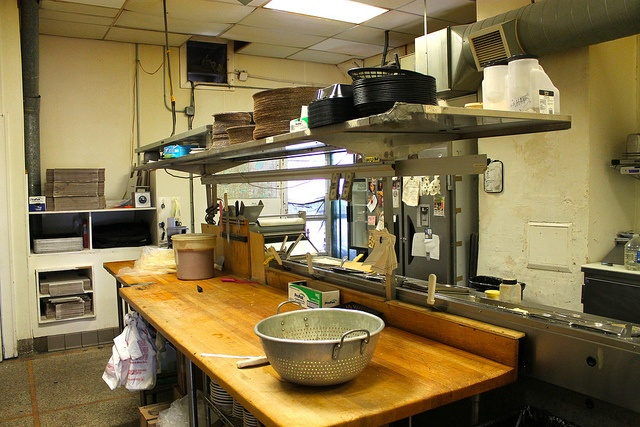

In [ ]:
from ultralytics import YOLO

results = yolo_model.predict(
    source="/content/drive/MyDrive/smartvision/smartvision_dataset/detection/images/image_001458.jpg",
    device="cpu",
    conf=0.25,
    save=True
)

results[0].show()

In [ ]:
results[0].save()

'results_image_001458.jpg'

In [ ]:
                                                                          # Post-processing


In [ ]:
# Run YOLO

In [ ]:
results = yolo_model.predict(
    source=img_path,
    device="cpu",
    conf=0.25,   # initial threshold
    save=False
)


image 1/1 /content/drive/MyDrive/smartvision/smartvision_dataset/detection/images/image_001458.jpg: 96x128 (no detections), 14.4ms
Speed: 0.6ms preprocess, 14.4ms inference, 0.5ms postprocess per image at shape (1, 3, 96, 128)


In [ ]:
# Extract boxes

In [ ]:
boxes = results[0].boxes

In [ ]:
# Apply Confidence Filter

In [ ]:
filtered_boxes = []

for box in boxes:
    conf = float(box.conf[0])

    if conf > 0.5:   # 50% threshold
        filtered_boxes.append(box)

In [ ]:
# NMS (manual demonstration)

In [ ]:
import torchvision.ops as ops
import torch

if len(filtered_boxes) > 0:
    xyxy = torch.stack([b.xyxy[0] for b in filtered_boxes])
    scores = torch.tensor([float(b.conf[0]) for b in filtered_boxes])

    keep = ops.nms(xyxy, scores, iou_threshold=0.5)

    final_boxes = [filtered_boxes[i] for i in keep]
else:
    final_boxes = []

In [ ]:
# Visualization

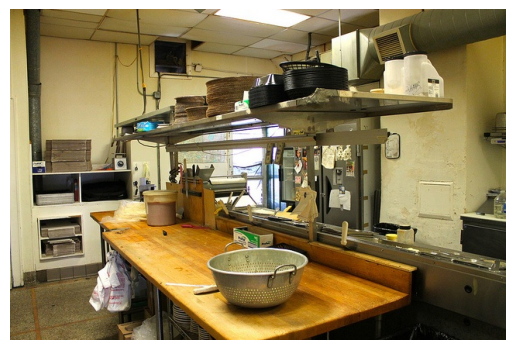

In [ ]:
import cv2

img = cv2.imread(img_path)

for box in final_boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])
    cls = int(box.cls[0])

    label = f"Class {cls} {conf:.2f}"

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(img, label, (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
# Performance Optimization


In [ ]:
# GPU Acceleration

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

yolo_model.to(device)
cnn_model.to(device)

Using device: cpu


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Model Quantization

In [ ]:
import torch

cnn_model.eval()

# dynamic quantization (recommended for CNN)
quantized_model = torch.quantization.quantize_dynamic(
    cnn_model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

print("CNN quantized ✔")

CNN quantized ✔


/tmp/ipykernel_9239/3152460027.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [ ]:
# Batch Processing

In [ ]:
import glob

img_paths = glob.glob(
    "/content/drive/MyDrive/smartvision/smartvision_dataset/detection/images/train/*.jpg"
)

batch = img_paths[:10]  # first 10 images

In [ ]:
# Batch YOLO inference

In [ ]:
results = yolo_model.predict(
    source=batch,
    device=device,
    conf=0.25,
    save=True
)


0: 128x128 (no detections), 16.5ms
1: 128x128 (no detections), 16.5ms
2: 128x128 (no detections), 16.5ms
3: 128x128 (no detections), 16.5ms
4: 128x128 (no detections), 16.5ms
5: 128x128 (no detections), 16.5ms
6: 128x128 (no detections), 16.5ms
7: 128x128 (no detections), 16.5ms
8: 128x128 (no detections), 16.5ms
9: 128x128 (no detections), 16.5ms
Speed: 0.6ms preprocess, 16.5ms inference, 0.2ms postprocess per image at shape (1, 3, 128, 128)
Results saved to /content/runs/detect/predict-2


In [ ]:
# Memory Optimization

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Lightweight inference mode

In [ ]:
yolo_model.fuse()  # speeds up conv layers

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1))
          (act): SiLU(inplace=True)
        )
        (m): ModuleList(
          (0): Bottleneck(
            (cv1): Conv(
              (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplace=True)
            )
            (cv2): Conv(
              (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (act): SiLU(inplace=True)
   